# Castor Fiber findings - Team 2527

0. Iteration setup
Before importing anything in the File. The first step is to create a virtual enviroment via terminal. The following must be installed in order for the entire assignment to work properly (Excluing hashes)

# Install the rest of the libraries by using pip install [library name]

### On Window's Powershell

In [2]:
python3 -m venv venv # Create the virtual enviroment
.\venv\Scripts\Activate.ps1 # enter into the enviroment

SyntaxError: invalid syntax (3690538898.py, line 1)

### On MacOS/Linux

In [ ]:
python3 -m venv venv # Create the virtual enviroment
source venv/bin/activate # enter into the enviroment

- importing libraries and datasets
- merging both datasets into one data set 
- implementing a longitude and latitude column into the merged dataframe

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.preprocessing import StandardScaler

species_df = pd.read_csv("Castor fiber.csv", low_memory=False)
habitat_df = pd.read_csv("habitats_cbs_2022.csv")

df = species_df.merge(
    habitat_df,
    on=["decimalLongitude", "decimalLatitude"],
    how="left"
)

- gathering information on the dataset 
- describing the type of data the column has
- fetching the first 5 columns and see the data provided and what does it include.

In [3]:
df.info()
df.describe()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 15 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Castor fiber               str    
 6   agricultural               float64
 7   built                      float64
 8   coast                      float64
 9   forest                     float64
 10  other                      float64
 11  sand/heather               float64
 12  water                      float64
 13  wetland                    float64
 14  main_habitat               str    
dtypes: float64(11), int64(1), str(3)
memory usage: 1.4 GB


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Castor fiber,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
1,50.75,5.65,2010-01-02,26.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
2,50.75,5.65,2010-01-03,3.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural


- Check if there is any duplacate data in the dataframe 
- We used it by adding the number of duplacates by using ".sum()" 

In [4]:
#Check duplicates
df.duplicated().sum()

np.int64(0)

- With the number being 0, there are no signs of duplacates in the dataset

- Check if there is ant missing values in the dataframe
- Just like last time, we used ".sum()" to identify the number of mussing values
- the count of missing values should be grater than 0
- those that are 0 or less, are not included.

In [5]:
# missing values
missing_values = df.isna().sum()
missing_values[missing_values > 0]


total_observations     4
agricultural          30
built                 30
coast                 30
forest                30
other                 30
sand/heather          30
water                 30
wetland               30
main_habitat          30
dtype: int64

- the minumum of missing values is 4, for total obervations
- those can be either a human error, corruption or not aplicable
- the maximum of missinng values is 30, from the habitat of the observation.
- decimalLatitude, decimalLongitude, eventDate, peciesgroup_observations and Castor fiber	are the only ones that have no missing values

- Check the persentage of missing values
- the missing persentage must have a value higher than 0
- those who have less than 0 will be excluded

In [6]:
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent[missing_percent > 0]

total_observations    0.000032
agricultural          0.000239
built                 0.000239
coast                 0.000239
forest                0.000239
other                 0.000239
sand/heather          0.000239
water                 0.000239
wetland               0.000239
main_habitat          0.000239
dtype: float64

- the lowest missing persentage is 0.000032
- the higheste is 0.000239
- those persentages are considered to be minor and dont have a servere impact on the data set.

- Because of the low number of missing values, those do not be modified and only remove the missing values.
- gather the columms that have had missing values and "Drop" the ones that have had missing values.
- To check the number of missing values again, we used ".Sum()". 
- If the sum is zero, then that means that all of the missing values are gone.

In [7]:
habitat_cols = [
    "agricultural", "built", "coast", "forest", "other",
    "sand/heather", "water", "wetland", "main_habitat"
]

df = df.dropna(subset=habitat_cols)
df = df.dropna(subset=["total_observations"])

df.isna().sum()

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Castor fiber                 0
agricultural                 0
built                        0
coast                        0
forest                       0
other                        0
sand/heather                 0
water                        0
wetland                      0
main_habitat                 0
dtype: int64

- Check the data types to see if there is anything that might need a change

In [8]:
df.dtypes

decimalLatitude              float64
decimalLongitude             float64
eventDate                        str
total_observations           float64
speciesgroup_observations      int64
Castor fiber                     str
agricultural                 float64
built                        float64
coast                        float64
forest                       float64
other                        float64
sand/heather                 float64
water                        float64
wetland                      float64
main_habitat                     str
dtype: object

- Notice that "eventDate", which is a string, would have worked better if it was a datetime64
- Strings are mostly used for displaying text
- Datetime is used to display the date and/or time of the data

- Notice that "Castor fiber", which is a string, would have worked better if it was a numeric intreger
- Strings are mostly used for displaying text, but knowing that it is a number...
- Intreger is used to display the value or number of the column

In [9]:

df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")
df["Castor fiber"] = pd.to_numeric(df["Castor fiber"], errors="coerce")

- Check the data type again to see if the column's type has changed

In [10]:
df.dtypes

decimalLatitude                     float64
decimalLongitude                    float64
eventDate                    datetime64[us]
total_observations                  float64
speciesgroup_observations             int64
Castor fiber                          int64
agricultural                        float64
built                               float64
coast                               float64
forest                              float64
other                               float64
sand/heather                        float64
water                               float64
wetland                             float64
main_habitat                            str
dtype: object

- The data has been changed with sucsses.

- We used a boxplot in order to determine the number of Castor fiber observations without zerovalues
- Those that have values lass or equal to zero are excluded on the diagram

In [11]:
# Remove impossible negative observations
df = df[df["Castor fiber"] >= 0]

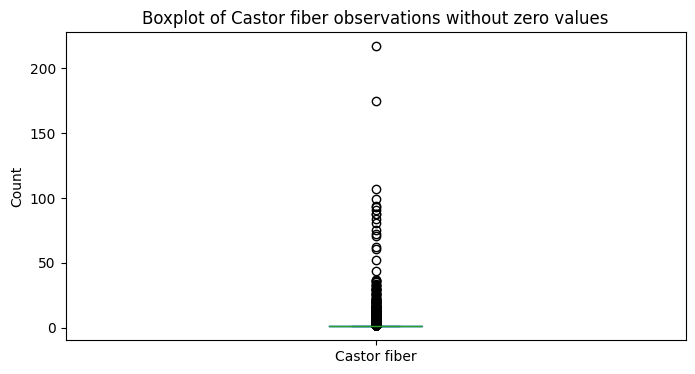

In [12]:
import matplotlib.pyplot as plt

castor_nonzero = df[df["Castor fiber"] > 0]

plt.figure(figsize=(8, 4))
castor_nonzero["Castor fiber"].plot(kind="box")
plt.title("Boxplot of Castor fiber observations without zero values")
plt.ylabel("Count")
plt.show()

- most observations even without zero values tend to be low
- most of the observations number are below 50, but several dozen are below 100
- the maximum number of observations are above 200.

- in order to find out the yearly observations we used a line cart.
- the line cart will include the years as the xlabel and the number of observations as the ylabel

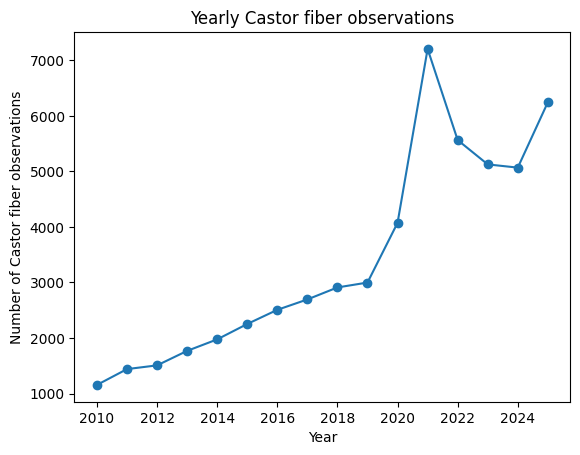

In [13]:
import matplotlib.pyplot as plt

# 1. Create the 'year' column by extracting it from 'eventDate'
df['year'] = df['eventDate'].dt.year

# 2. Group by your brand new 'year' column and sum the observations
yearly_castor = df.groupby("year")["Castor fiber"].sum()

# 3. Plot the data
yearly_castor.plot(kind="line", marker="o")
plt.title("Yearly Castor fiber observations")
plt.xlabel("Year")
plt.ylabel("Number of Castor fiber observations")
plt.show()

- there has been a rise of observations in the year 2022.
- A small decrease in 2023 and rose back in the last year.
- the graph is left skewed

In [14]:
df.describe()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Castor fiber,agricultural,built,coast,forest,other,sand/heather,water,wetland,year
count,1.255876e+07,1.255876e+07,12558756,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07
mean,5.223006e+01,5.532783e+00,2017-12-31 11:59:59.999999,8.114858e+00,2.216673e-01,4.339443e-03,9.452277e+00,2.404833e+00,1.302932e+00,1.621184e+00,1.501486e+00,1.881532e-01,1.245543e+00,2.249716e-01,2.017500e+03
min,5.075000e+01,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.010000e+03
25%,5.170000e+01,4.900000e+00,2013-12-31 18:00:00,0.000000e+00,0.000000e+00,0.000000e+00,5.348400e+00,7.667000e-01,0.000000e+00,1.494000e-01,7.249000e-01,0.000000e+00,9.900000e-02,0.000000e+00,2.013750e+03
50%,5.220000e+01,5.650000e+00,2017-12-31 12:00:00,1.000000e+00,0.000000e+00,0.000000e+00,1.056820e+01,1.559900e+00,0.000000e+00,7.092000e-01,1.199800e+00,0.000000e+00,3.102000e-01,1.820000e-02,2.017500e+03
75%,5.280000e+01,6.200000e+00,2021-12-31 06:00:00,6.000000e+00,0.000000e+00,0.000000e+00,1.380080e+01,3.291600e+00,0.000000e+00,2.036400e+00,2.006500e+00,2.340000e-02,1.033000e+00,1.417000e-01,2.021250e+03
max,5.350000e+01,7.200000e+00,2025-12-31 00:00:00,1.000400e+05,1.637000e+03,2.170000e+02,1.810460e+01,1.435380e+01,1.934870e+01,1.699850e+01,1.039830e+01,1.034430e+01,1.890870e+01,1.422410e+01,2.025000e+03
std,6.605211e-01,8.748856e-01,NaN,3.920192e+01,1.974649e+00,1.606455e-01,5.147907e+00,2.419758e+00,3.970215e+00,2.385737e+00,1.167872e+00,7.709894e-01,2.688194e+00,7.063523e-01,4.609698e+00


In [15]:
weather_df = pd.read_csv(
    r"Weather.csv.txt",
    comment="#",
    header=None,
    names=["STN", "YYYYMMDD", "FG", "TG", "TN", "TX", "SQ", "RH", "UG"],
    sep=",",
    skipinitialspace=True
)

weather_df.head()

,STN,YYYYMMDD,FG,TG,TN,TX,SQ,RH,UG
0,260,20100101,38,-16,-63,7,42,-1,78
1,260,20100102,31,-11,-64,12,0,1,91
2,260,20100103,25,-39,-65,-10,62,0,84
3,260,20100104,31,-29,-54,-6,10,-1,90
4,260,20100105,28,-7,-30,19,33,9,91


In [16]:
# Convert YYYYMMDD to real date
weather_df["date"] = pd.to_datetime(
    weather_df["YYYYMMDD"].astype(str),
    format="%Y%m%d"
)

# Convert KNMI units
weather_df["FG"] = weather_df["FG"] / 10   # average wind speed in m/s
weather_df["TG"] = weather_df["TG"] / 10   # average temperature in °C
weather_df["TN"] = weather_df["TN"] / 10   # minimum temperature in °C
weather_df["TX"] = weather_df["TX"] / 10   # maximum temperature in °C

# KNMI uses -1 for very small sunshine/rain values, so replace with 0
weather_df["SQ"] = weather_df["SQ"].replace(-1, 0) / 10   # sunshine duration in hours
weather_df["RH"] = weather_df["RH"].replace(-1, 0) / 10   # precipitation in mm

# UG is humidity percentage, so keep it unchanged

In [17]:
weather_df = weather_df[["date", "FG", "TG", "TN", "TX", "SQ", "RH", "UG"]]

weather_df = weather_df.rename(columns={
    "FG": "avg_wind_speed",
    "TG": "avg_temperature",
    "TN": "min_temperature",
    "TX": "max_temperature",
    "SQ": "sunshine_duration",
    "RH": "precipitation",
    "UG": "avg_humidity"
})

weather_df.head()

,date,avg_wind_speed,avg_temperature,min_temperature,max_temperature,sunshine_duration,precipitation,avg_humidity
0,2010-01-01,3.8,-1.6,-6.3,0.7,4.2,0.0,78
1,2010-01-02,3.1,-1.1,-6.4,1.2,0.0,0.1,91
2,2010-01-03,2.5,-3.9,-6.5,-1.0,6.2,0.0,84
3,2010-01-04,3.1,-2.9,-5.4,-0.6,1.0,0.0,90
4,2010-01-05,2.8,-0.7,-3.0,1.9,3.3,0.9,91


In [18]:
df = df.merge(
    weather_df,
    left_on="eventDate",
    right_on="date",
    how="left"
)

df = df.drop(columns=["date"])


In [19]:
weather_cols = [
    "avg_temperature",
    "min_temperature",
    "max_temperature",
    "precipitation",
    "sunshine_duration",
    "avg_wind_speed",
    "avg_humidity"
]

df[weather_cols].isna().sum()

avg_temperature      0
min_temperature      0
max_temperature      0
precipitation        0
sunshine_duration    0
avg_wind_speed       0
avg_humidity         0
dtype: int64

In [20]:
df = df.dropna(subset=weather_cols)

In [21]:
df["year"] = df["eventDate"].dt.year
df["month"] = df["eventDate"].dt.month
df["day_of_week"] = df["eventDate"].dt.dayofweek
def get_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

df["season"] = df["month"].apply(get_season)

In [22]:
df["castor_present"] = (df["Castor fiber"] > 0).astype(int)

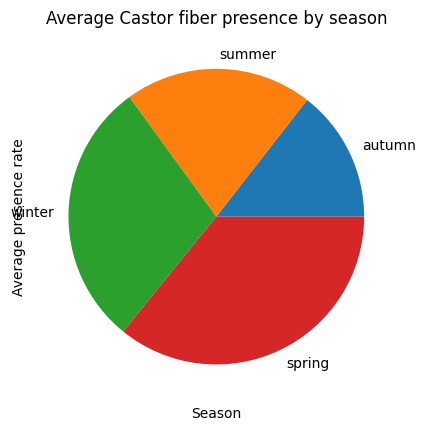

In [23]:
season_counts = (
    df.groupby(by="season")["castor_present"]
    .mean()
    .sort_values()
)

season_counts.plot(kind="pie")
plt.title("Average Castor fiber presence by season")
plt.xlabel("Season")
plt.ylabel("Average presence rate")
plt.show()

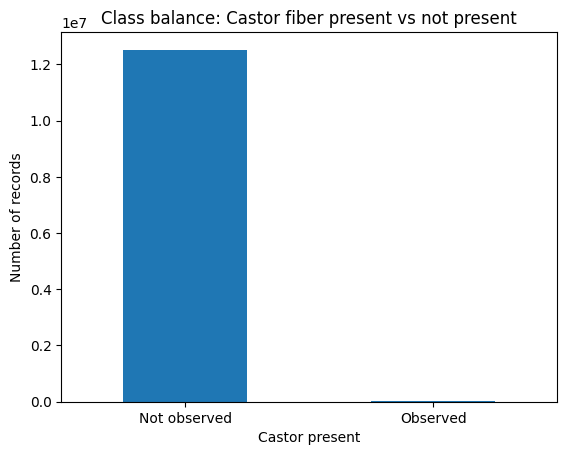

In [24]:
df["castor_present"].value_counts().plot(kind="bar")

plt.title("Class balance: Castor fiber present vs not present")
plt.xlabel("Castor present")
plt.ylabel("Number of records")
plt.xticks([0, 1], ["Not observed", "Observed"], rotation=0)
plt.show()

In [25]:
import numpy as np

df["total_observations_log"] = np.log1p(df["total_observations"])
df["speciesgroup_observations_log"] = np.log1p(df["speciesgroup_observations"])

In [26]:
df = pd.get_dummies(
    df,
    columns=["main_habitat", "season"],
    drop_first=True
)

In [27]:
df["castor_present"].value_counts(normalize=True) * 100
df["castor_present"].value_counts(normalize=True) * 100

castor_present
0    99.69501
1     0.30499
Name: proportion, dtype: float64

In [ ]:
from sklearn.model_selection import train_test_split

target = "castor_present"


columns_to_drop = [
    "Castor fiber",
    "castor_present",
    "eventDate",
    "decimalLatitude",
    "decimalLongitude",
    "total_observations",
    "speciesgroup_observations",
    "precipitation"
]

X = df.drop(columns=columns_to_drop)
y = df["castor_present"]

X = X.select_dtypes(include=["number", "bool"])

print("Features used:")
print(X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

Features used:
['agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland', 'year', 'avg_wind_speed', 'avg_temperature', 'min_temperature', 'max_temperature', 'sunshine_duration', 'precipitation', 'avg_humidity', 'month', 'day_of_week', 'total_observations_log', 'speciesgroup_observations_log', 'main_habitat_built', 'main_habitat_coast', 'main_habitat_forest', 'main_habitat_other', 'main_habitat_sand/heather', 'main_habitat_water', 'main_habitat_wetland', 'season_spring', 'season_summer', 'season_winter']
X shape: (12558756, 30)
y shape: (12558756,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("BASELINE MODEL")
print(classification_report(y_test, baseline_pred, zero_division=0))

BASELINE MODEL
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2504091
           1       0.00      0.00      0.00      7661

    accuracy                           1.00   2511752
   macro avg       0.50      0.50      0.50   2511752
weighted avg       0.99      1.00      1.00   2511752



In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
rf_pred = rf_model.predict(X_test)

# Evaluate the model
print("RANDOM FOREST MODEL")
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred, zero_division=0))

RANDOM FOREST MODEL
[[2504076      15]
 [   7649      12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2504091
           1       0.44      0.00      0.00      7661

    accuracy                           1.00   2511752
   macro avg       0.72      0.50      0.50   2511752
weighted avg       1.00      1.00      1.00   2511752



In [39]:


# Combine X_train and y_train
train_df = X_train.copy()
train_df["castor_present"] = y_train.values

# Split into positive and negative training rows
positive_train = train_df[train_df["castor_present"] == 1]
negative_train = train_df[train_df["castor_present"] == 0]

print("Positive training rows:", len(positive_train))
print("Negative training rows:", len(negative_train))

# Sample 3x as many negative rows as positive rows
negative_train_sampled = negative_train.sample(
    n=len(positive_train) * 3,
    random_state=42
)

# Combine positive rows with sampled negative rows
train_1_to_3 = pd.concat(
    [positive_train, negative_train_sampled],
    axis=0
).sample(frac=1, random_state=42)

# Split back into X and y
X_train_1_to_3 = train_1_to_3.drop(columns=["castor_present"])
y_train_1_to_3 = train_1_to_3["castor_present"]

print("1:3 balanced training data:")
print(y_train_1_to_3.value_counts())

Positive training rows: 30642
Negative training rows: 10016362
1:3 balanced training data:
castor_present
0    91926
1    30642
Name: count, dtype: int64


In [40]:
rf_1_to_3 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=5
)

rf_1_to_3.fit(X_train_1_to_3, y_train_1_to_3)

rf_1_to_3_pred = rf_1_to_3.predict(X_test)

print("RANDOM FOREST 1:3 BALANCED TRAINING DATA")
print(confusion_matrix(y_test, rf_1_to_3_pred))
print(classification_report(y_test, rf_1_to_3_pred, zero_division=0))

RANDOM FOREST 1:3 BALANCED TRAINING DATA
[[2365822  138269]
 [   2145    5516]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97   2504091
           1       0.04      0.72      0.07      7661

    accuracy                           0.94   2511752
   macro avg       0.52      0.83      0.52   2511752
weighted avg       1.00      0.94      0.97   2511752



In [41]:
feature_importance_1_to_3 = pd.DataFrame({
    "feature": X_train_1_to_3.columns,
    "importance": rf_1_to_3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_1_to_3.head(15)

,feature,importance
18,total_observations_log,0.171766
6,water,0.146052
3,forest,0.098926
0,agricultural,0.065548
1,built,0.064128
4,other,0.061688
19,speciesgroup_observations_log,0.051018
7,wetland,0.045209
8,year,0.043015
5,sand/heather,0.032762


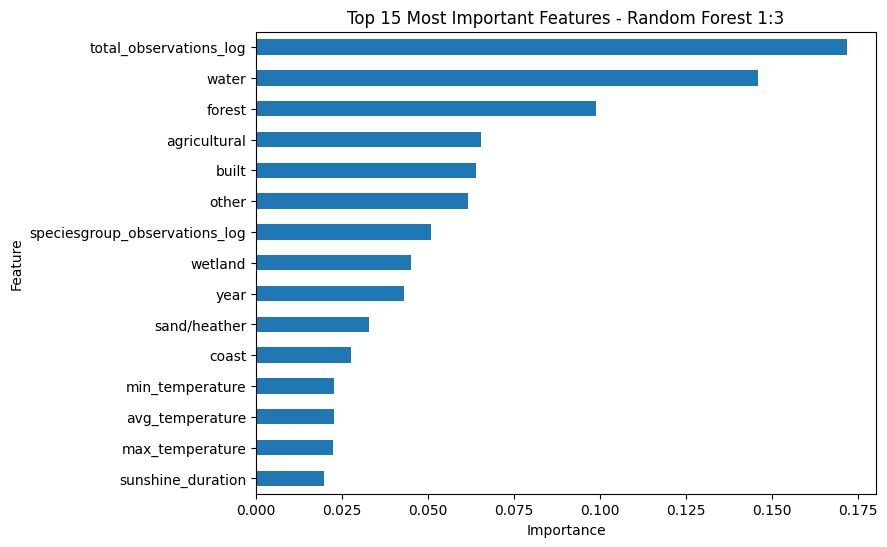

In [43]:
feature_importance_1_to_3.head(15).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8, 6),
    legend=False
)

plt.title("Top 15 Most Important Features - Random Forest 1:3")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [44]:


def train_rf_with_ratio(X_train, y_train, X_test, y_test, negative_ratio):
    train_df = X_train.copy()
    train_df["castor_present"] = y_train.values

    positive_train = train_df[train_df["castor_present"] == 1]
    negative_train = train_df[train_df["castor_present"] == 0]

    negative_train_sampled = negative_train.sample(
        n=len(positive_train) * negative_ratio,
        random_state=42
    )

    balanced_train = pd.concat(
        [positive_train, negative_train_sampled],
        axis=0
    ).sample(frac=1, random_state=42)

    X_train_balanced = balanced_train.drop(columns=["castor_present"])
    y_train_balanced = balanced_train["castor_present"]

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=5
    )

    model.fit(X_train_balanced, y_train_balanced)
    pred = model.predict(X_test)

    print(f"RANDOM FOREST 1:{negative_ratio} BALANCED TRAINING DATA")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, zero_division=0))

    return model, pred

In [45]:
rf_1_to_5, pred_1_to_5 = train_rf_with_ratio(
    X_train, y_train, X_test, y_test, negative_ratio=5
)

RANDOM FOREST 1:5 BALANCED TRAINING DATA
[[2422662   81429]
 [   3015    4646]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98   2504091
           1       0.05      0.61      0.10      7661

    accuracy                           0.97   2511752
   macro avg       0.53      0.79      0.54   2511752
weighted avg       1.00      0.97      0.98   2511752



In [46]:
rf_1_to_10, pred_1_to_10 = train_rf_with_ratio(
    X_train, y_train, X_test, y_test, negative_ratio=10
)

RANDOM FOREST 1:10 BALANCED TRAINING DATA
[[2467502   36589]
 [   4365    3296]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   2504091
           1       0.08      0.43      0.14      7661

    accuracy                           0.98   2511752
   macro avg       0.54      0.71      0.57   2511752
weighted avg       1.00      0.98      0.99   2511752



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def get_model_scores(name, y_test, pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_class_1": precision_score(y_test, pred, zero_division=0),
        "recall_class_1": recall_score(y_test, pred, zero_division=0),
        "f1_class_1": f1_score(y_test, pred, zero_division=0)
    }

results = []

results.append(get_model_scores("Random Forest 1:3", y_test, rf_1_to_3_pred))
results.append(get_model_scores("Random Forest 1:5", y_test, pred_1_to_5))
results.append(get_model_scores("Random Forest 1:10", y_test, pred_1_to_10))

results_df = pd.DataFrame(results)
results_df

NameError: name 'accuracy_score' is not defined

In [ ]:
from sklearn.preprocessing import StandardScaler

features_to_scale = [
    "decimalLatitude",
    "decimalLongitude",
    "year",
    "month",
    "day_of_week",
    "total_observations_log",
    "speciesgroup_observations_log",
    "avg_temperature",
    "min_temperature",
    "max_temperature",
    "precipitation",
    "sunshine_duration",
    "avg_wind_speed",
    "avg_humidity"
]

scaler = StandardScaler()

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])